In [1]:
import pandas as pd
from SCPIntModel import *

In [2]:
import scanpy as sc

In [3]:
multibatch_ann = sc.read_h5ad('../data/task_data/lps_ann.h5ad')

In [4]:
multibatch_ann

AnnData object with n_obs × n_vars = 1863 × 714
    obs: 'celltype', 'batch'
    uns: 'pca'
    obsm: 'X_pca', 'X_tsne', 'X_umap'
    varm: 'PCs'

In [5]:
processor = AnnDataProcessor(multibatch_ann, batch_key="batch")

Loaded 1863 cells × 714 proteins
Batches (2): ['huffman', 'specht']


In [6]:
loader  = processor.make_dataloader(batch_size=128)

In [7]:
 # 构建模型
model = scProteoIntegrator(
    n_genes   = processor.n_genes,
    n_batches = processor.n_batches,
)

In [8]:
lambda_cls=0.4
lambda_adv=0.1
lambda_mse=0.5
lr = 0.01
epochs = 1000
warmup = 1
md = 'lps'

In [9]:
trainer = Trainer(model, lr=lr, lambda_cls=lambda_cls, lambda_adv=lambda_adv,lambda_mse=lambda_mse, lr_reduc_factor=0.9)

In [10]:
trainer.fit(loader, n_epochs=epochs, adv_warmup_epochs=warmup)

Epoch   10 | total=3.0314 | recon=1.3657 | mse=0.9098 | cls=0.0550 | adv=11.8879 |lr=0.009000000000000001
Epoch   20 | total=2.0166 | recon=1.3574 | mse=0.8995 | cls=0.0009 | adv=2.0910 |lr=0.007290000000000001
Epoch   30 | total=1.8769 | recon=1.3496 | mse=0.8875 | cls=0.0186 | adv=0.7614 |lr=0.007290000000000001
Epoch   40 | total=2.5902 | recon=1.3442 | mse=0.8825 | cls=0.0102 | adv=8.0068 |lr=0.006561000000000002
Epoch   50 | total=2.9089 | recon=1.3415 | mse=0.8796 | cls=0.0019 | adv=11.2677 |lr=0.005314410000000002
Epoch   60 | total=3.7509 | recon=1.3348 | mse=0.8718 | cls=0.0026 | adv=19.7911 |lr=0.004304672100000002
Epoch   70 | total=2.3677 | recon=1.3328 | mse=0.8694 | cls=0.0015 | adv=5.9958 |lr=0.003874204890000002
Epoch   80 | total=1.8432 | recon=1.3384 | mse=0.8753 | cls=0.0009 | adv=0.6685 |lr=0.003486784401000002
Epoch   90 | total=1.8414 | recon=1.3272 | mse=0.8624 | cls=0.0267 | adv=0.7233 |lr=0.003486784401000002
Epoch  100 | total=1.7792 | recon=1.3110 | mse=0.845

In [11]:
model_name = f"{md}_cls-{lambda_cls}_adv-{lambda_adv}_mse-{lambda_mse}_warmup-{warmup}_lr-{lr}_epoch-{epochs}"

损失曲线已保存至: ../data/model/lps_cls-0.4_adv-0.1_mse-0.5_warmup-1_lr-0.01_epoch-1000.svg


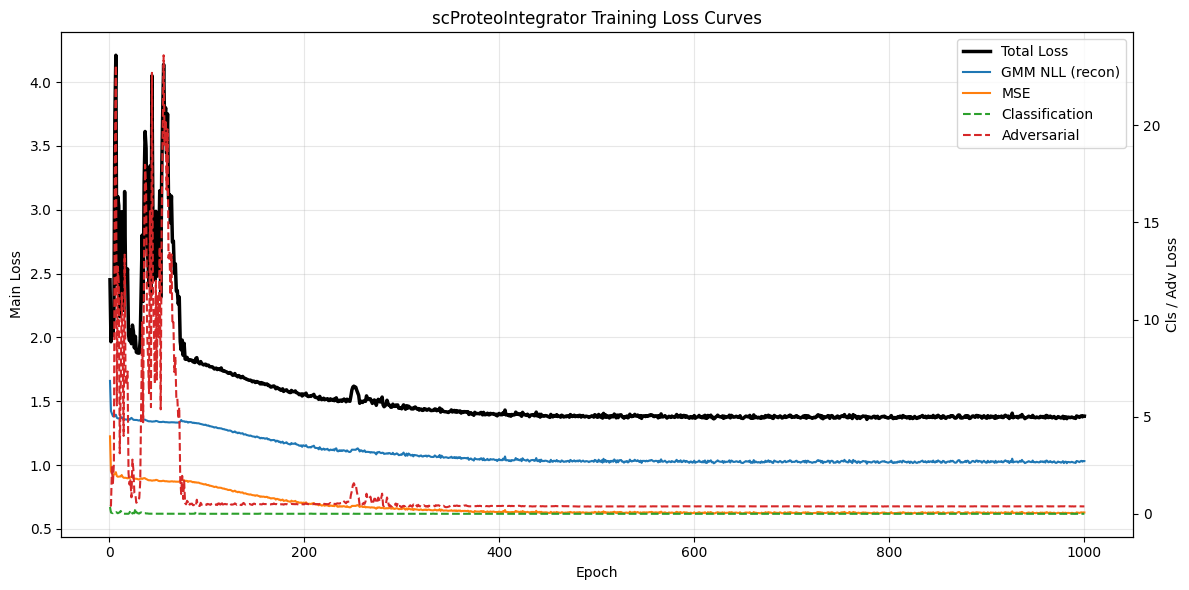

In [12]:
trainer.plot_losses(
    save_path=f"../data/model/{model_name}.svg",   # 可改成任意路径
    show=True                      # False 则只保存不弹窗
)

In [13]:
trainer.save(f"../data/model/{model_name}.pt")

Model saved to ../data/model/lps_cls-0.4_adv-0.1_mse-0.5_warmup-1_lr-0.01_epoch-1000.pt
